In [ ]:
# ==================================
# File: inspect_gene_correlations.ipynb
# ==================================
# NOTE:
# これは notebook 用の「1ブロック表現」です。
# 実際には Jupyter 上で `# %%` ごとにセル分割して使う想定です。

# %% [markdown]
# # Gene-wise velocity correlation inspection (Erythropoietic only)
#
# 入力:
# - compute_velocity_metrics.py
#   - gene_metrics_eryth.parquet
#   - velocities_eryth.npz
#   - adata_eryth_base.h5ad
# - embed_velocity.py
#   - adata_eryth_embedded.h5ad
#
# 目的:
# - pearson_r の分布を見る
# - r ≈ -1 かつ velocity 振幅が十分ある遺伝子を候補化
# - 候補を保存しつつ目視で絞る
# - expression + 全体ベクトル場 / gene-specific velocity color を見る

In [1]:
# %%
import os
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.sparse as sp
import seaborn as sns
from typing import Optional

sns.set_context("talk")

In [2]:

# %%
# -----------------------------
# 0. run dir を解決
# -----------------------------
RUN_DIR = "/home/suzuki/Projects/scDiffusion/work/20260215_embryonic/20260330_Analyze-20260224Lamda5/20260330_072038_velocity_compare"  # 例: "/absolute/path/to/20260330_123456_velocity_compare"

if RUN_DIR is None:
    latest_run_txt = Path(os.getcwd()) / "latest_velocity_compare_run.txt"
    if not latest_run_txt.exists():
        raise FileNotFoundError(
            f"{latest_run_txt} not found. "
            "compute_velocity_metrics.py を同じ作業ディレクトリで実行してください。"
        )
    RUN_DIR = Path(latest_run_txt.read_text(encoding="utf-8").strip())
else:
    RUN_DIR = Path(RUN_DIR)

print(f"RUN_DIR = {RUN_DIR}")

RUN_DIR = /home/suzuki/Projects/scDiffusion/work/20260215_embryonic/20260330_Analyze-20260224Lamda5/20260330_072038_velocity_compare


In [3]:
# %%
# -----------------------------
# 1. paths
# -----------------------------
METRICS_PATH = RUN_DIR / "gene_metrics_eryth.parquet"
VELOCITY_NPZ_PATH = RUN_DIR / "velocities_eryth.npz"
ADATA_EMBEDDED_PATH = RUN_DIR / "adata_eryth_embedded.h5ad"

FIG_DIR = RUN_DIR / "fig_gene_inspection_eryth"
FIG_DIR.mkdir(parents=True, exist_ok=True)

MODEL1_KEY = "V1"
MODEL2_KEY = "V2"
BASIS = "umap"

QUIVER_MAX_ARROWS = 1500
RANDOM_SEED = 0

In [4]:
# %%
# -----------------------------
# 2. load
# -----------------------------
metrics_df = pd.read_parquet(METRICS_PATH)
adata = ad.read_h5ad(ADATA_EMBEDDED_PATH)
vel_data = np.load(VELOCITY_NPZ_PATH, allow_pickle=True)

V1 = np.asarray(vel_data["V1"], dtype=np.float32)
V2 = np.asarray(vel_data["V2"], dtype=np.float32)
obs_names_npz = vel_data["obs_names"].astype(str)
var_names_npz = vel_data["var_names"].astype(str)

print(metrics_df.shape)
print(adata)
print(V1.shape, V2.shape)

(1024, 19)
AnnData object with n_obs × n_vars = 36639 × 1024
    obs: 'Age', 'ClassAnn', 'Souporcell', 'Subclass', 'Superclass', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'assay_ontology_term_id', 'development_stage_ontology_term_id', 'donor_id', 'suspension_type', 'tissue_type', 'dissection', 'fraction_mitochondrial', 'fraction_unspliced', 'total_genes', 'total_UMIs', 'sample_id', 'celltype', 'cluster_id', 'cell_type_ontology_term_id', 'tissue_ontology_term_id', 'is_primary_data', 'sex_ontology_term_id', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes', 'V1_self_transition', 'V2_self_transition', 'root_cells', 'end_points', 'V1_pseudotime', 'V2_pseudotime'
    var: 'Chromosome', 'End', 'gene_name', 'Start', 'Strand', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'n_cells', 'highly_variable', 'means', 'dispersi

In [5]:
# %%
# -----------------------------
# 3. sanity check
# -----------------------------
if not np.array_equal(obs_names_npz, adata.obs_names.astype(str).to_numpy()):
    raise ValueError("obs_names mismatch between npz and adata_embedded")

if not np.array_equal(var_names_npz, adata.var_names.astype(str).to_numpy()):
    raise ValueError("var_names mismatch between npz and adata_embedded")

basis_key = f"X_{BASIS}"
vel_basis_key1 = f"{MODEL1_KEY}_{BASIS}"
vel_basis_key2 = f"{MODEL2_KEY}_{BASIS}"

for key in [basis_key, vel_basis_key1, vel_basis_key2]:
    if key not in adata.obsm:
        raise KeyError(f"{key} not found in adata.obsm")

required_metric_cols = [
    "gene",
    "pearson_r",
    "pearson_r2",
    "spearman_r",
    "slope",
    "intercept",
    "mean_abs_v1",
    "mean_abs_v2",
    "std_v1",
    "std_v2",
]
for col in required_metric_cols:
    if col not in metrics_df.columns:
        raise KeyError(f"{col} not found in metrics_df")

In [18]:
# %%
# -----------------------------
# 4. helper
# -----------------------------
gene_to_idx = {g: i for i, g in enumerate(adata.var_names.astype(str))}

def get_gene_index(gene: str) -> int:
    if gene not in gene_to_idx:
        raise KeyError(f"{gene} not found in adata.var_names")
    return gene_to_idx[gene]

def get_expr_vector(gene: str) -> np.ndarray:
    idx = get_gene_index(gene)
    x = adata[:, idx].X
    if sp.issparse(x):
        x = x.toarray()
    x = np.asarray(x).reshape(-1).astype(float)
    x[~np.isfinite(x)] = 0.0
    return x

def get_velocity_vector(vmat: np.ndarray, gene: str) -> np.ndarray:
    idx = get_gene_index(gene)
    v = np.asarray(vmat[:, idx], dtype=float).reshape(-1)
    v[~np.isfinite(v)] = 0.0
    return v

def subsample_indices(n: int, max_points: int, seed: int = 0) -> np.ndarray:
    if n <= max_points:
        return np.arange(n)
    rng = np.random.default_rng(seed)
    return np.sort(rng.choice(n, size=max_points, replace=False))

def add_quiver(ax, coords: np.ndarray, vel2d: np.ndarray, max_arrows: int = 1500, seed: int = 0):
    idx = subsample_indices(coords.shape[0], max_arrows, seed=seed)
    ax.quiver(
        coords[idx, 0],
        coords[idx, 1],
        vel2d[idx, 0],
        vel2d[idx, 1],
        angles="xy",
        scale_units="xy",
        scale=None,
        width=0.002,
        alpha=0.6,
    )

def plot_embedding_color(ax, coords: np.ndarray, values: np.ndarray, title: str, cmap="viridis"):
    sca = ax.scatter(
        coords[:, 0],
        coords[:, 1],
        c=values,
        s=6,
        cmap=cmap,
        linewidths=0,
    )
    ax.set_title(title)
    ax.set_xlabel(f"{BASIS}_1")
    ax.set_ylabel(f"{BASIS}_2")
    plt.colorbar(sca, ax=ax, fraction=0.046, pad=0.04)

def plot_scatter_v1_v2(ax, v1: np.ndarray, v2: np.ndarray, gene: str, row: pd.Series):
    ax.scatter(v1, v2, s=8, alpha=0.35, linewidths=0)

    finite_mask = np.isfinite(v1) & np.isfinite(v2)
    vv1 = v1[finite_mask]
    vv2 = v2[finite_mask]

    if vv1.size > 0:
        xmin, xmax = np.quantile(vv1, [0.01, 0.99])
        ymin, ymax = np.quantile(vv2, [0.01, 0.99])
        lim_min = min(xmin, ymin)
        lim_max = max(xmax, ymax)

        ax.plot([lim_min, lim_max], [lim_min, lim_max], linestyle="--", linewidth=1)
        ax.plot([lim_min, lim_max], [-lim_min, -lim_max], linestyle=":", linewidth=1)

    ax.set_title(
        f"{gene}\n"
        f"pearson={row['pearson_r']:.3f}, "
        # f"spearman={row['spearman_r']:.3f}, "
        # f"slope={row['slope']:.3f}"
    )
    ax.set_xlabel("v1")
    ax.set_ylabel("v2")

def plot_gene_report(
    gene: str,
    metrics_df: pd.DataFrame,
    adata: ad.AnnData,
    V1: np.ndarray,
    V2: np.ndarray,
    basis: str = "umap",
    fig_dir: Optional[Path] = None,
    show: bool = True,
    quiver_max_arrows: int = 1500,
    seed: int = 0,
):
    row = metrics_df.loc[metrics_df["gene"] == gene]
    if row.shape[0] == 0:
        raise KeyError(f"{gene} not found in metrics_df")
    row = row.iloc[0]

    coords = np.asarray(adata.obsm[f"X_{basis}"])
    vel2d_1 = np.asarray(adata.obsm[f"{MODEL1_KEY}_{basis}"])
    vel2d_2 = np.asarray(adata.obsm[f"{MODEL2_KEY}_{basis}"])

    expr = get_expr_vector(gene)
    v1 = get_velocity_vector(V1, gene)
    v2 = get_velocity_vector(V2, gene)

    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    axes = axes.ravel()

    # 1. scatter
    plot_scatter_v1_v2(axes[0], v1, v2, gene, row)

    # 2. expression + model1 field
    plot_embedding_color(axes[1], coords, expr, f"{gene} expression + {MODEL1_KEY} field", cmap="viridis")
    add_quiver(axes[1], coords, vel2d_1, max_arrows=quiver_max_arrows, seed=seed)

    # 3. expression + model2 field
    plot_embedding_color(axes[2], coords, expr, f"{gene} expression + {MODEL2_KEY} field", cmap="viridis")
    add_quiver(axes[2], coords, vel2d_2, max_arrows=quiver_max_arrows, seed=seed)

    # 4. gene-specific velocity color (V1)
    plot_embedding_color(axes[3], coords, v1, f"{gene} velocity in {MODEL1_KEY}", cmap="coolwarm")

    # 5. gene-specific velocity color (V2)
    plot_embedding_color(axes[4], coords, v2, f"{gene} velocity in {MODEL2_KEY}", cmap="coolwarm")

    # 6. summary text
    axes[5].axis("off")
    summary_text = "\n".join([
        f"gene: {gene}",
        f"pearson_r:    {row['pearson_r']:.6f}",
        f"pearson_r2:   {row['pearson_r2']:.6f}",
        f"spearman_r:   {row['spearman_r']:.6f}",
        f"slope:        {row['slope']:.6f}",
        f"intercept:    {row['intercept']:.6f}",
        f"mean_abs_v1:  {row['mean_abs_v1']:.6e}",
        f"mean_abs_v2:  {row['mean_abs_v2']:.6e}",
        f"std_v1:       {row['std_v1']:.6e}",
        f"std_v2:       {row['std_v2']:.6e}",
        f"n_valid:      {int(row['n_valid_cells'])}",
        f"frac_zero_v1: {row.get('frac_zero_v1', np.nan):.6f}",
        f"frac_zero_v2: {row.get('frac_zero_v2', np.nan):.6f}",
    ])
    axes[5].text(0.0, 1.0, summary_text, va="top", ha="left", family="monospace", fontsize=12)

    fig.suptitle(f"Gene report: {gene}", fontsize=20)
    fig.tight_layout()

    if fig_dir is not None:
        fig_dir.mkdir(parents=True, exist_ok=True)
        fig.savefig(fig_dir / f"{gene}.png", dpi=200, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)




* distibution of pearson_r, spearman_rは、学習前途のVelcity (V1, V2)に対してピアソン・スピアマン相関係数の頻度分布
* pearson_r vs min_mean_abs_vは遺伝子のvelcotityの絶対値（V1, V2のうち小さい方）をy座標、ピアソン相関係数をx座標にした散布図

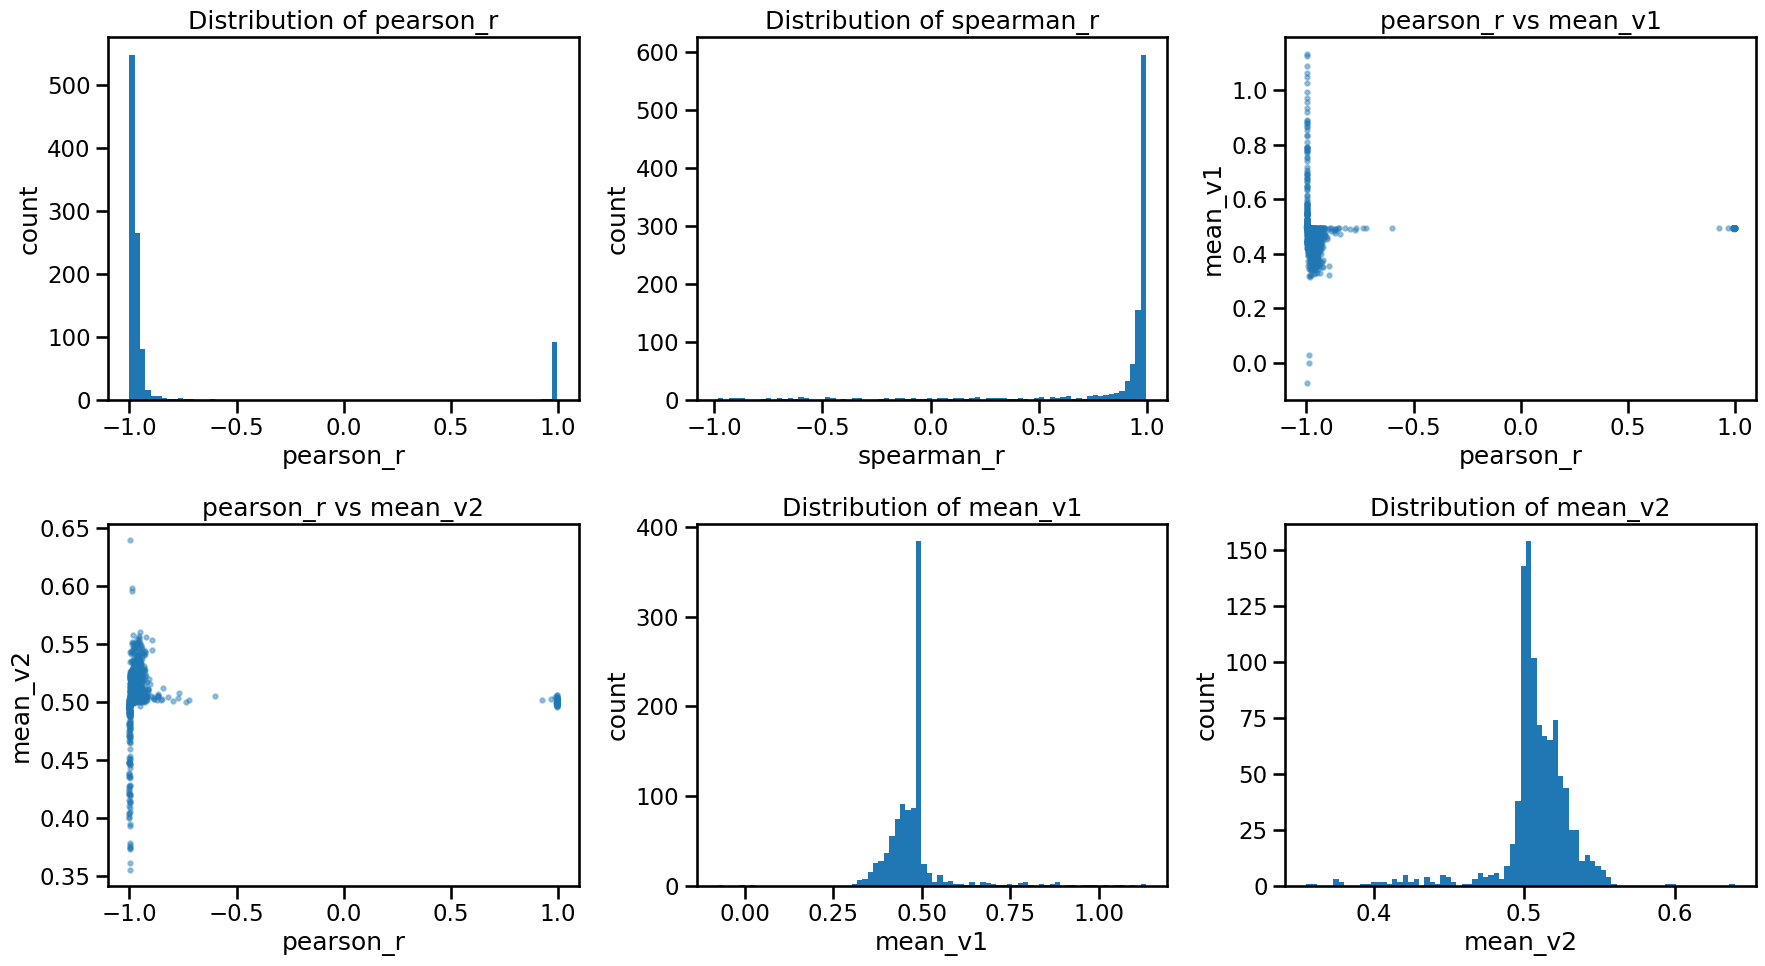

In [9]:
# -----------------------------
# 5. metrics distribution (2x3)
# -----------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# flattenして扱いやすくする
axes = axes.ravel()

# ---- 1行目 ----
# pearson
axes[0].hist(metrics_df["pearson_r"].dropna(), bins=80)
axes[0].set_title("Distribution of pearson_r")
axes[0].set_xlabel("pearson_r")
axes[0].set_ylabel("count")

# spearman
axes[1].hist(metrics_df["spearman_r"].dropna(), bins=80)
axes[1].set_title("Distribution of spearman_r")
axes[1].set_xlabel("spearman_r")
axes[1].set_ylabel("count")

# pearson vs signal
axes[2].scatter(
    metrics_df["pearson_r"],
    metrics_df["mean_v1"],
    s=10,
    alpha=0.4,
)
axes[2].set_title("pearson_r vs mean_v1")
axes[2].set_xlabel("pearson_r")
axes[2].set_ylabel("mean_v1")

# ---- 2行目 ----
# pearson vs signal
axes[3].scatter(
    metrics_df["pearson_r"],
    metrics_df["mean_v2"],
    s=10,
    alpha=0.4,
)
axes[3].set_title("pearson_r vs mean_v2")
axes[3].set_xlabel("pearson_r")
axes[3].set_ylabel("mean_v2")

# mean_abs_v1
axes[4].hist(metrics_df["mean_v1"].dropna(), bins=80)
axes[4].set_title("Distribution of mean_v1")
axes[4].set_xlabel("mean_v1")
axes[4].set_ylabel("count")

# mean_abs_v2
axes[5].hist(metrics_df["mean_v2"].dropna(), bins=80)
axes[5].set_title("Distribution of mean_v2")
axes[5].set_xlabel("mean_v2")
axes[5].set_ylabel("count")

plt.tight_layout()
plt.show()

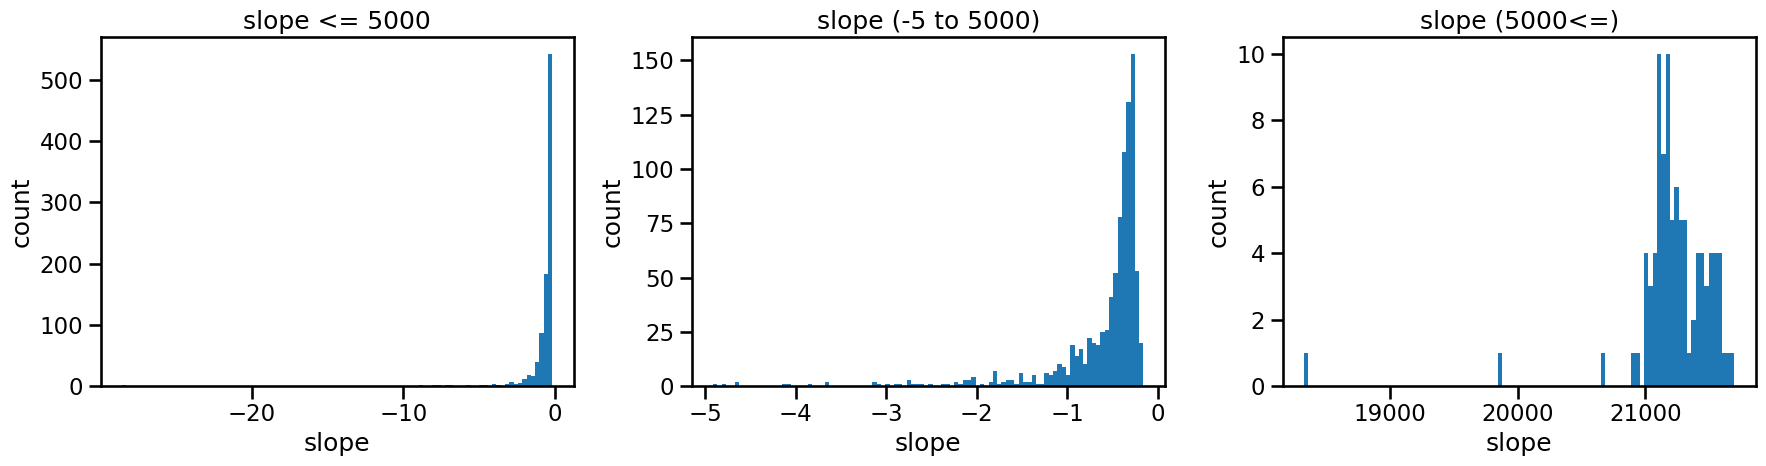

In [12]:
import matplotlib.pyplot as plt

# 条件①：<= 5000
slope_filtered_1 = metrics_df.loc[
    metrics_df["slope"].notna() & (metrics_df["slope"] <= 5000),
    "slope"
]

# 条件②：-5 ～ 5000
slope_filtered_2 = metrics_df.loc[
    metrics_df["slope"].notna() &
    (metrics_df["slope"] <= 5000) &
    (metrics_df["slope"] >= -5),
    "slope"
]

# 条件②：-5 ～ 5000
slope_filtered_3 = metrics_df.loc[
    metrics_df["slope"].notna() &
    (metrics_df["slope"] >= 5000),
    "slope"
]

# プロット
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 左：<=5000
axes[0].hist(slope_filtered_1, bins=100)
axes[0].set_title("slope <= 5000")
axes[0].set_xlabel("slope")
axes[0].set_ylabel("count")

# 右：-5～5000
axes[1].hist(slope_filtered_2, bins=100)
axes[1].set_title("slope (-5 to 5000)")
axes[1].set_xlabel("slope")
axes[1].set_ylabel("count")

# 右：-5～5000
axes[2].hist(slope_filtered_3, bins=100)
axes[2].set_title("slope (5000<=)")
axes[2].set_xlabel("slope")
axes[2].set_ylabel("count")
plt.tight_layout()
plt.show()

In [13]:
# %%
# -----------------------------
# 6. 自動候補の絞り込み
#   ※ ここは何度も触る前提
# -----------------------------
pearson_threshold = -0.90
min_mean_abs_v_threshold = metrics_df["min_mean_abs_v"].quantile(0.50)
min_std_v_threshold = metrics_df["min_std_v"].quantile(0.50)
max_frac_zero_threshold = 0.99

candidate_df = metrics_df.copy()
candidate_df = candidate_df[candidate_df["pearson_r"].notna()]
candidate_df = candidate_df[candidate_df["pearson_r"] <= pearson_threshold]
candidate_df = candidate_df[candidate_df["min_mean_abs_v"] >= min_mean_abs_v_threshold]
candidate_df = candidate_df[candidate_df["min_std_v"] >= min_std_v_threshold]

if "max_frac_zero_v" in candidate_df.columns:
    candidate_df = candidate_df[candidate_df["max_frac_zero_v"] <= max_frac_zero_threshold]

candidate_df = candidate_df.sort_values(
    by=["pearson_r", "min_mean_abs_v", "min_std_v"],
    ascending=[True, False, False],
).reset_index(drop=True)

display(
    candidate_df[
        [
            "gene",
            "pearson_r",
            "spearman_r",
            "slope",
            "mean_abs_v1",
            "mean_abs_v2",
            "std_v1",
            "std_v2",
            "frac_zero_v1",
            "frac_zero_v2",
        ]
    ].head(30)
)





,gene,pearson_r,spearman_r,slope,mean_abs_v1,mean_abs_v2,std_v1,std_v2,frac_zero_v1,frac_zero_v2
0,ENSG00000254942,-0.999653,0.982503,-1.807458,0.496831,0.505241,0.102366,0.185086,0.0,0.0
1,ENSG00000268812,-0.999606,0.786391,-0.493627,0.549057,0.509463,0.407899,0.201429,0.0,0.0
2,ENSG00000281450,-0.999604,0.986717,-0.533160,0.497229,0.502755,0.385385,0.205553,0.0,0.0
3,ENSG00000255395,-0.999587,0.968853,-0.518574,0.509726,0.506380,0.372725,0.193365,0.0,0.0
4,ENSG00000253666,-0.999581,0.962250,-1.051455,0.504264,0.511163,0.189863,0.199716,0.0,0.0
5,ENSG00000237254,-0.999576,0.978915,-2.196513,0.497368,0.509943,0.092319,0.202866,0.0,0.0
6,ENSG00000250337,-0.999561,0.966507,-0.520875,0.510840,0.509200,0.375080,0.195456,0.0,0.0
7,ENSG00000214049,-0.999559,0.327041,-0.295964,0.666012,0.475504,0.666424,0.197324,0.0,0.0
8,ENSG00000264464,-0.999559,0.991615,-0.351254,0.497339,0.496401,0.564034,0.198207,0.0,0.0
9,ENSG00000162897,-0.999558,0.985423,-0.419834,0.496872,0.503880,0.447112,0.187796,0.0,0.0


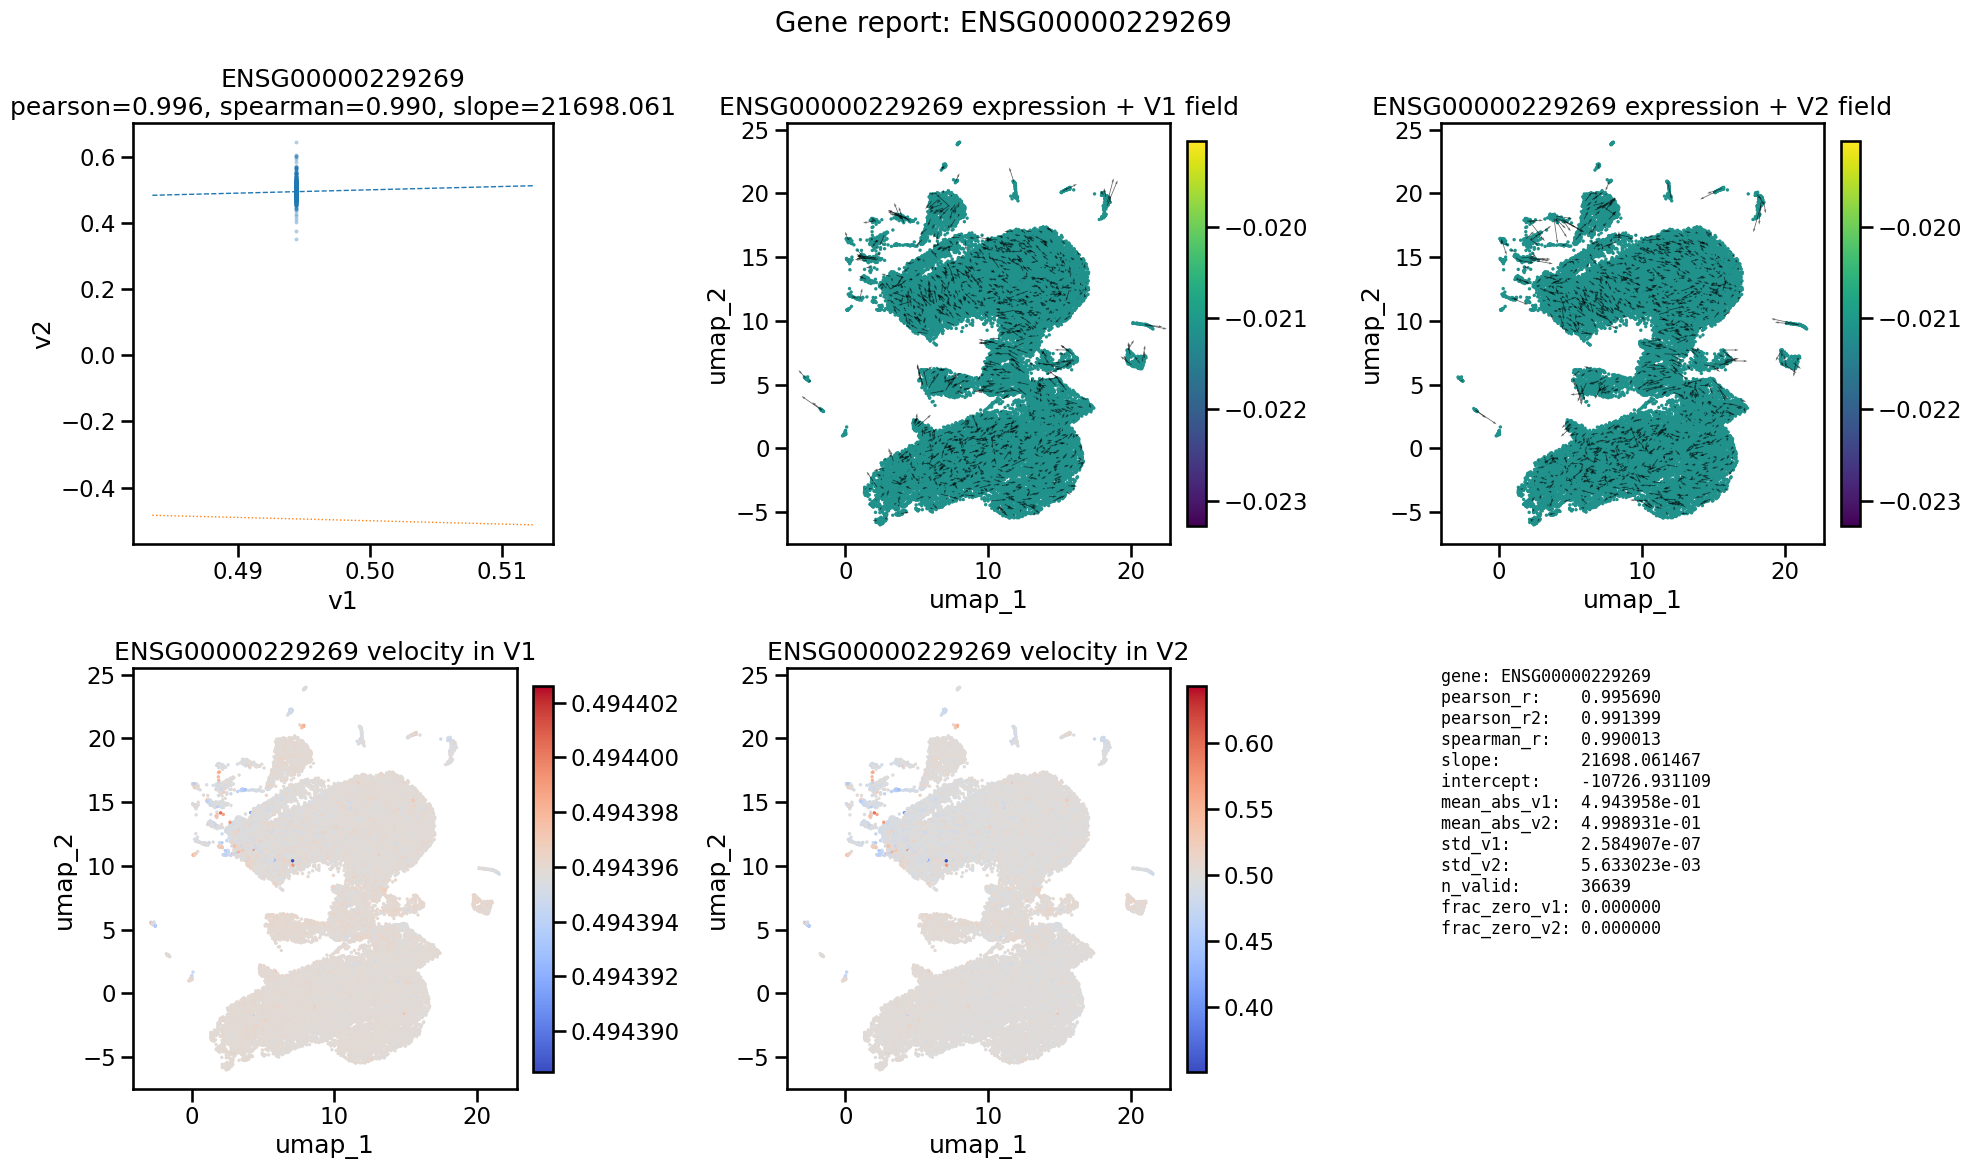

In [ ]:
# slopeが外れ値のもの：v1が完全に同じ値で計算されている
plot_gene_report(
    gene=metrics_df.sort_values("slope", ascending=False)["gene"].iloc[0],
    metrics_df=metrics_df,
    adata=adata,
    V1=V1,
    V2=V2,
    basis=BASIS,
    fig_dir=None,
    show=True,
    quiver_max_arrows=QUIVER_MAX_ARROWS,
    seed=RANDOM_SEED,
)

In [36]:
top_var_std_idx = adata.var.sort_values("std", ascending=False).index[:10]

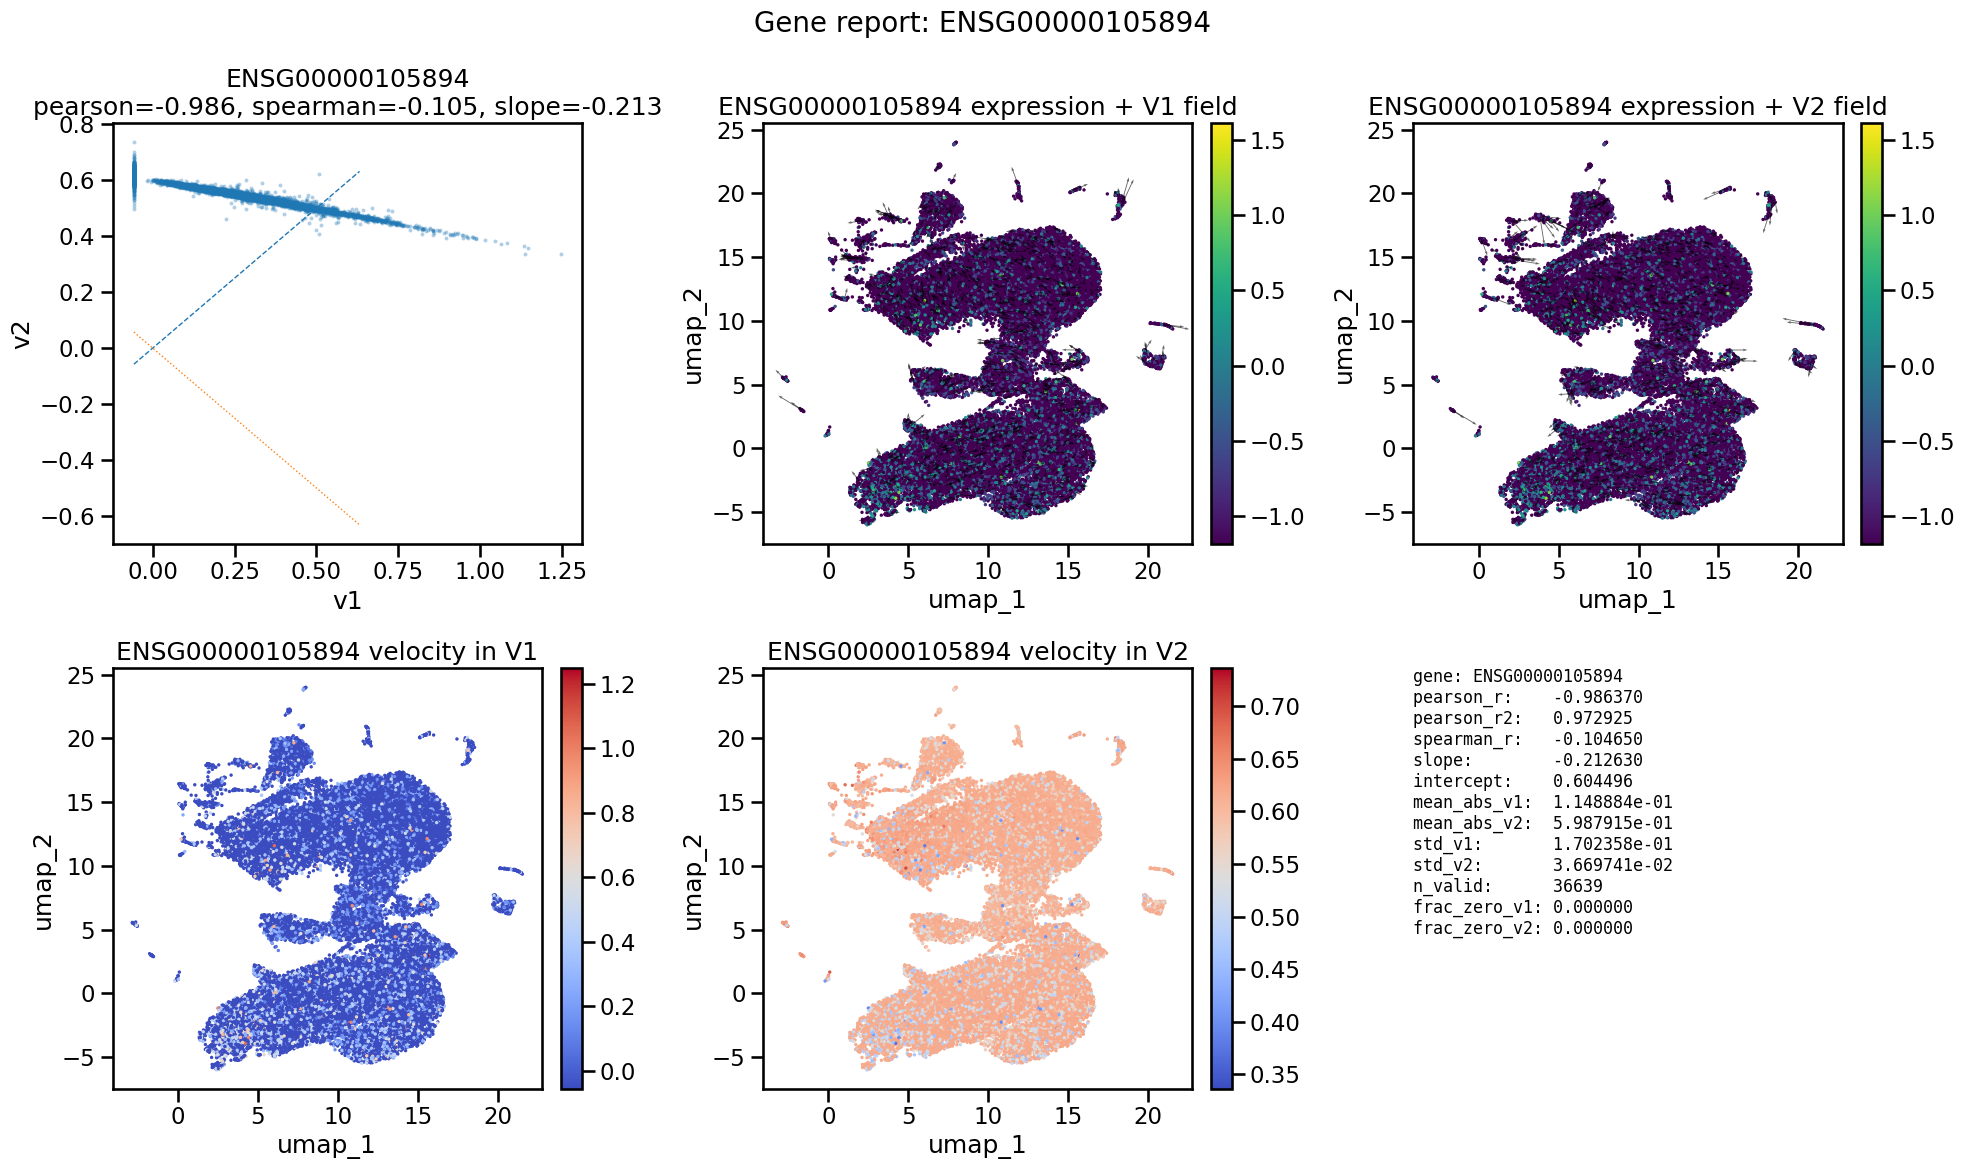

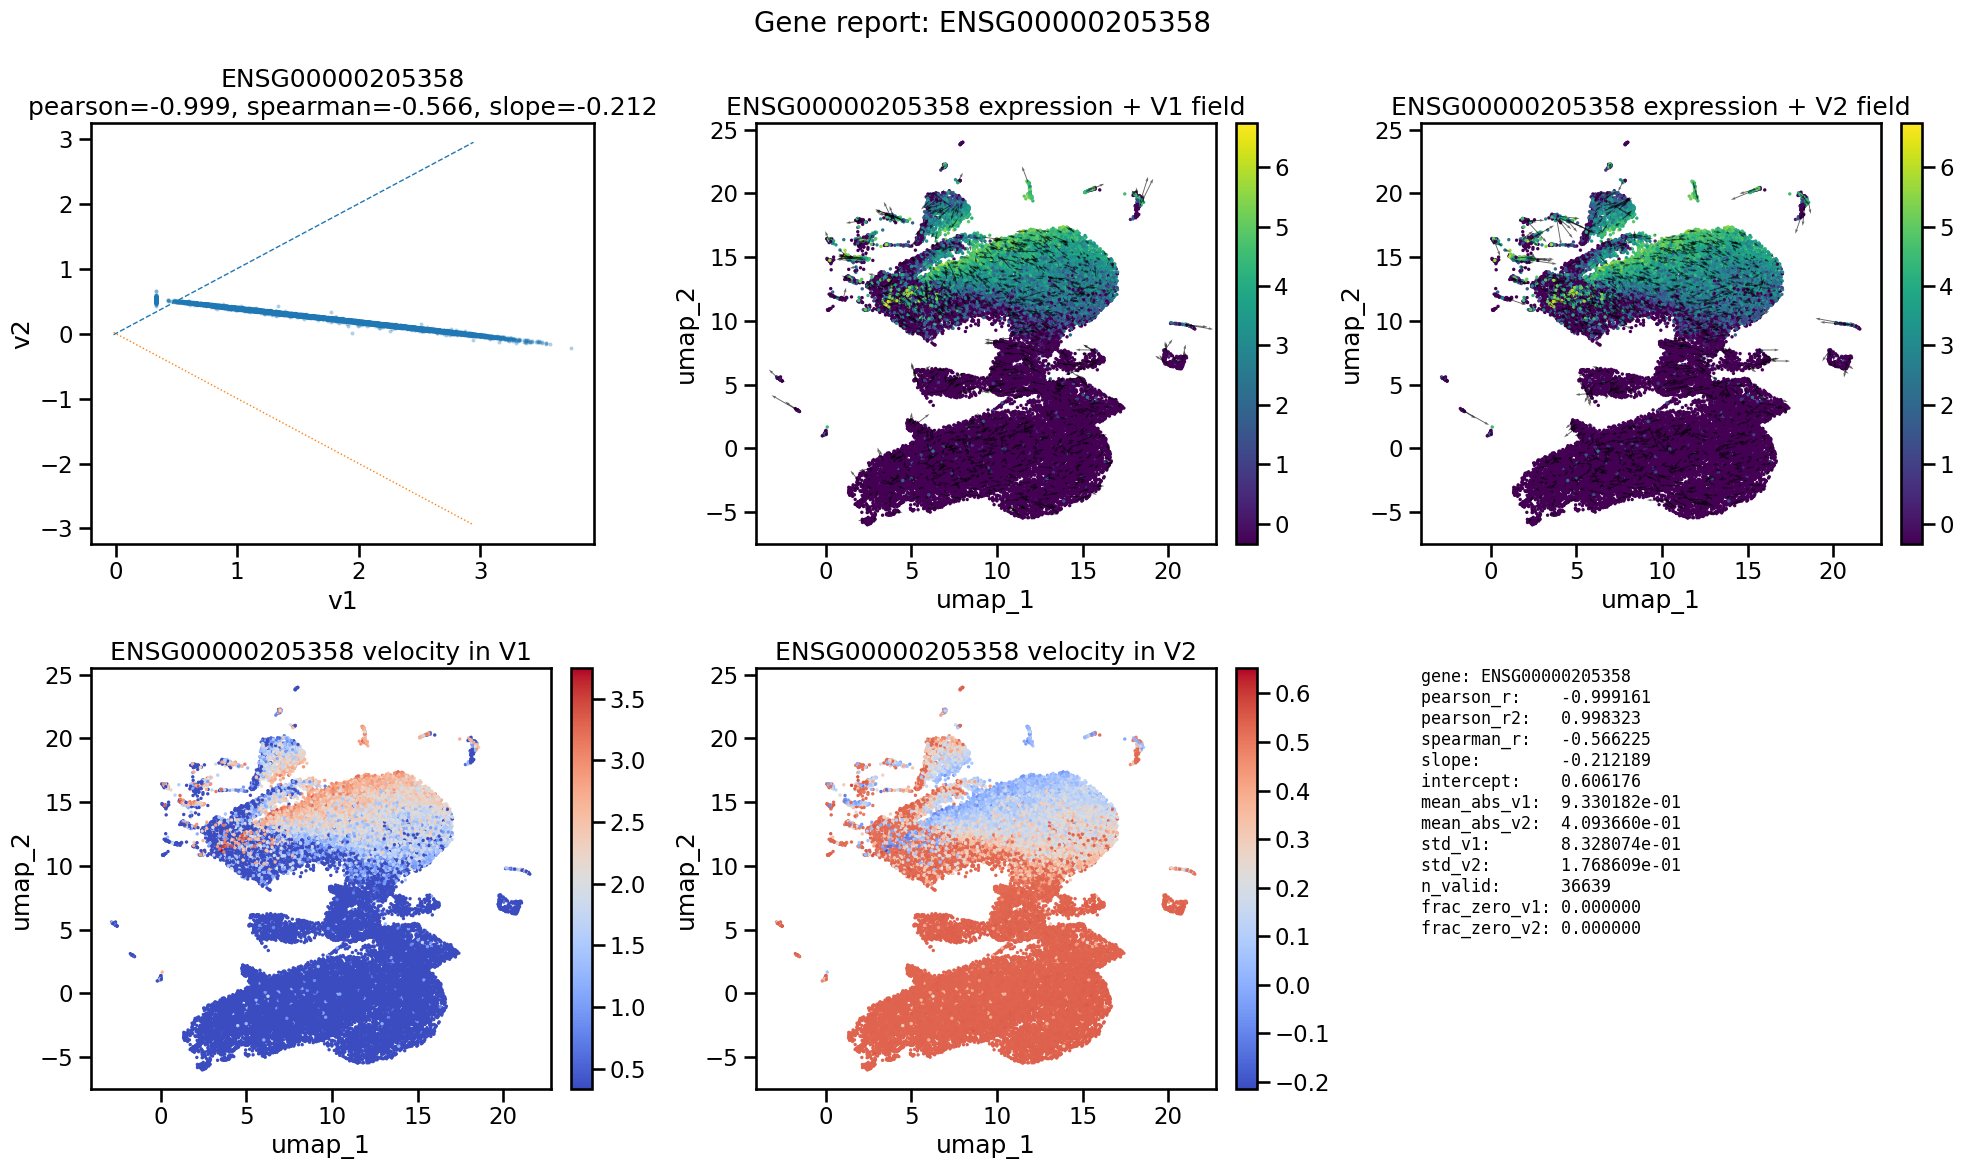

In [ ]:
# 発現に偏りがある場合の例
plot_gene_report(
    gene=top_var_std_idx[0],
    metrics_df=metrics_df,
    adata=adata,
    V1=V1,
    V2=V2,
    basis=BASIS,
    fig_dir=None,
    show=True,
    quiver_max_arrows=QUIVER_MAX_ARROWS,
    seed=RANDOM_SEED,
)

plot_gene_report(
    gene=top_var_std_idx[9],
    metrics_df=metrics_df,
    adata=adata,
    V1=V1,
    V2=V2,
    basis=BASIS,
    fig_dir=None,
    show=True,
    quiver_max_arrows=QUIVER_MAX_ARROWS,
    seed=RANDOM_SEED,
)

In [14]:

# %%
# -----------------------------
# 7. 初回スクリーニング遺伝子セット
#   ※ まずは上位候補を自動で保存
# -----------------------------
AUTO_TOP_N = 30
auto_genes = candidate_df["gene"].head(AUTO_TOP_N).tolist()

print(auto_genes[:10])
print(f"n_auto_genes={len(auto_genes)}")



['ENSG00000254942', 'ENSG00000268812', 'ENSG00000281450', 'ENSG00000255395', 'ENSG00000253666', 'ENSG00000237254', 'ENSG00000250337', 'ENSG00000214049', 'ENSG00000264464', 'ENSG00000162897']
n_auto_genes=30


30

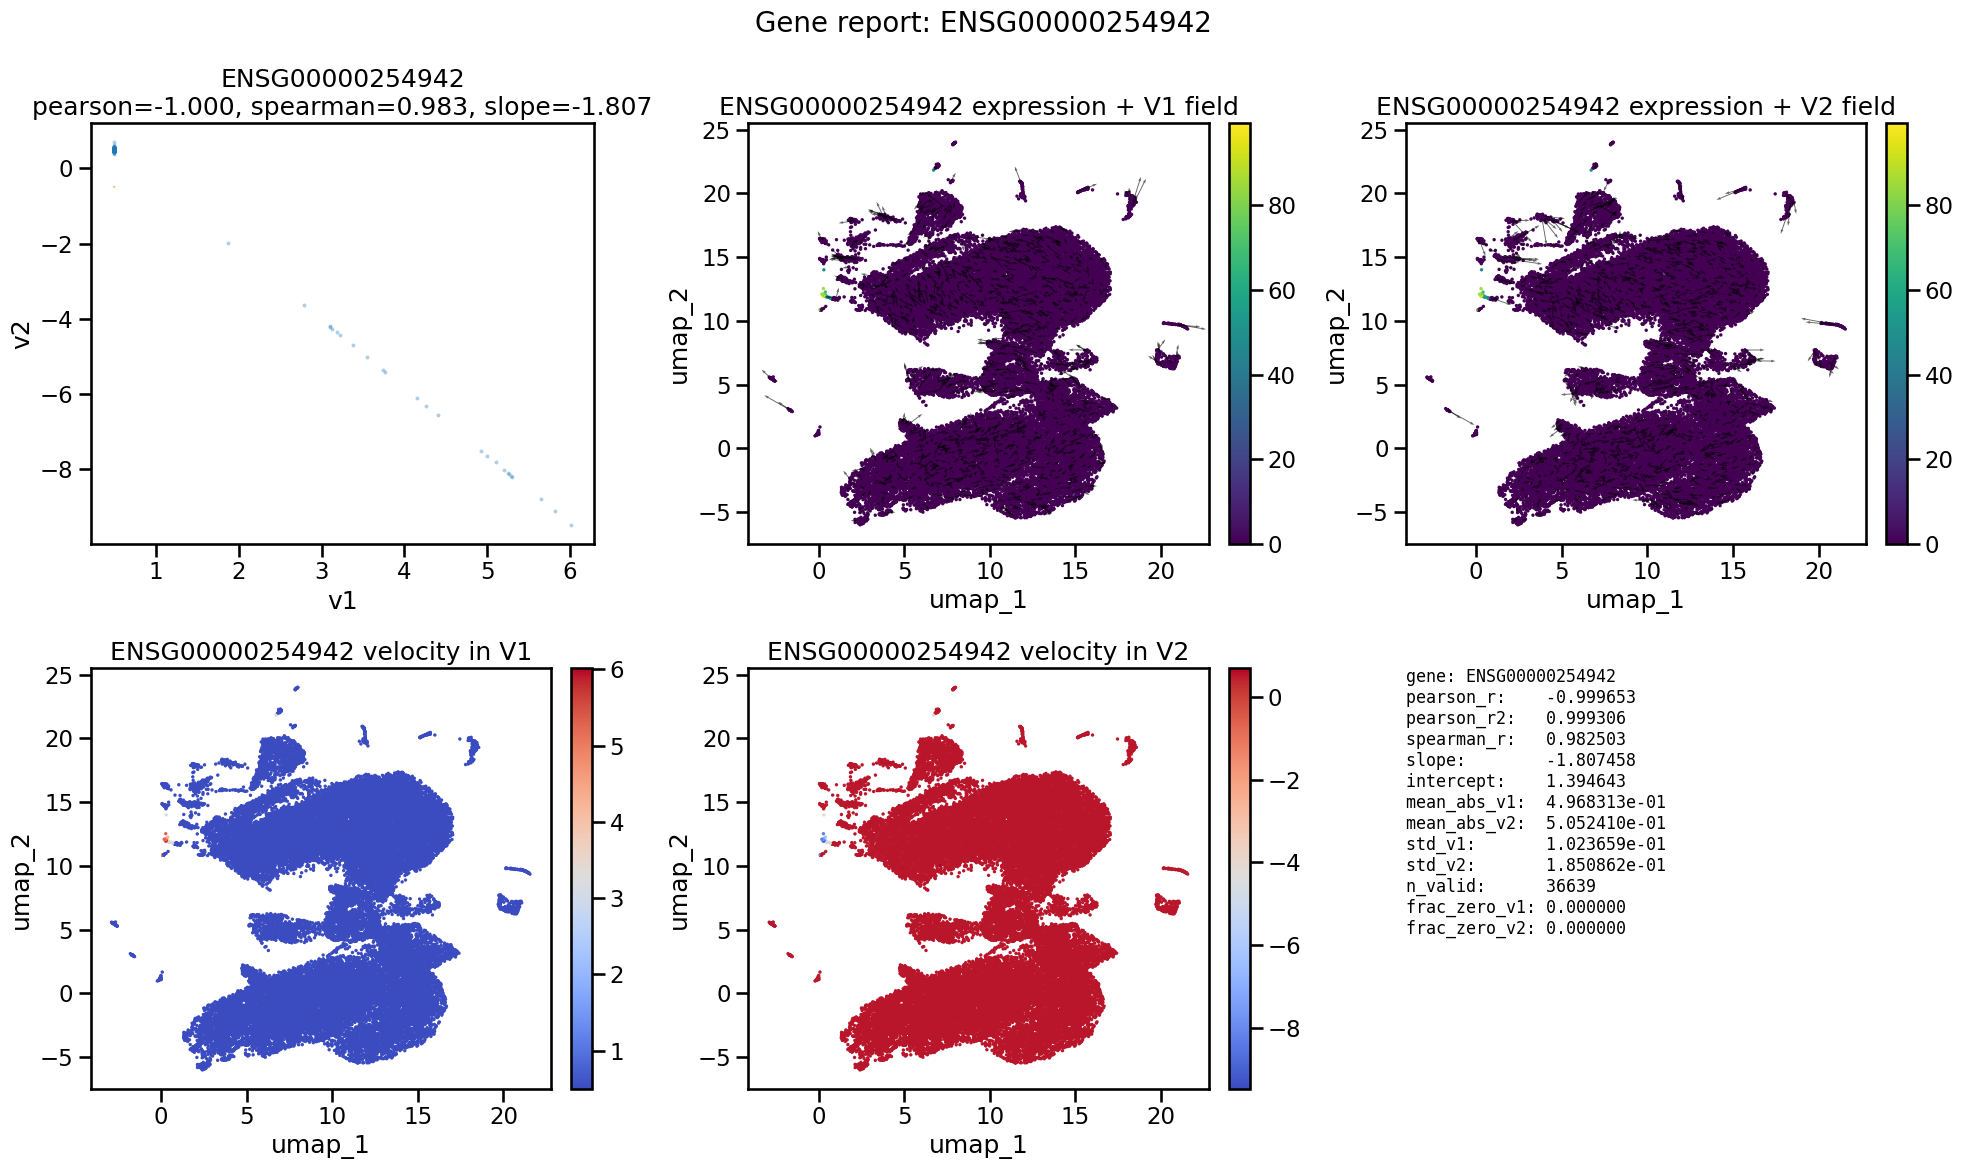

In [14]:
# %%
# -----------------------------
# 8. 単発確認
# -----------------------------
gene = auto_genes[0] if len(auto_genes) > 0 else None

if gene is not None:
    plot_gene_report(
        gene=gene,
        metrics_df=metrics_df,
        adata=adata,
        V1=V1,
        V2=V2,
        basis=BASIS,
        fig_dir=None,
        show=True,
        quiver_max_arrows=QUIVER_MAX_ARROWS,
        seed=RANDOM_SEED,
    )


In [ ]:

# %%
# -----------------------------
# 9. 自動候補をまとめて保存
#   ※ あなたの言う show=False + for で回す部分
# -----------------------------
screening_dir = FIG_DIR / "auto_screening_top_genes"
screening_dir.mkdir(parents=True, exist_ok=True)

for gene in auto_genes:
    plot_gene_report(
        gene=gene,
        metrics_df=metrics_df,
        adata=adata,
        V1=V1,
        V2=V2,
        basis=BASIS,
        fig_dir=screening_dir,
        show=False,
        quiver_max_arrows=QUIVER_MAX_ARROWS,
        seed=RANDOM_SEED,
    )

print(f"saved to: {screening_dir}")

saved to: /home/suzuki/Projects/scDiffusion/work/20260215_embryonic/20260330_Analyze-20260224Lamda5/20260330_072038_velocity_compare/fig_gene_inspection_eryth/auto_screening_top_genes


In [ ]:

# %%
# -----------------------------
# 10. manual curation
#   ※ 保存画像を見て本採用したい遺伝子だけを手で列挙
# -----------------------------
curated_genes = [
    # "GATA1",
    # "KLF1",
    # "HBA-X",
]

print(curated_genes)

In [ ]:
# %%
# -----------------------------
# 11. curated genes を最終保存
# -----------------------------
final_dir = FIG_DIR / "curated_genes"
final_dir.mkdir(parents=True, exist_ok=True)

for gene in curated_genes:
    plot_gene_report(
        gene=gene,
        metrics_df=metrics_df,
        adata=adata,
        V1=V1,
        V2=V2,
        basis=BASIS,
        fig_dir=final_dir,
        show=False,
        quiver_max_arrows=QUIVER_MAX_ARROWS,
        seed=RANDOM_SEED,
    )

print(f"saved to: {final_dir}")

In [ ]:
# -----------------------------
# 12. curated genes の metrics を保存
# -----------------------------
if len(curated_genes) > 0:
    curated_df = metrics_df[metrics_df["gene"].isin(curated_genes)].copy()
    curated_df = curated_df.sort_values("pearson_r")
    curated_df.to_csv(FIG_DIR / "curated_genes_metrics.csv", index=False)
    display(curated_df)

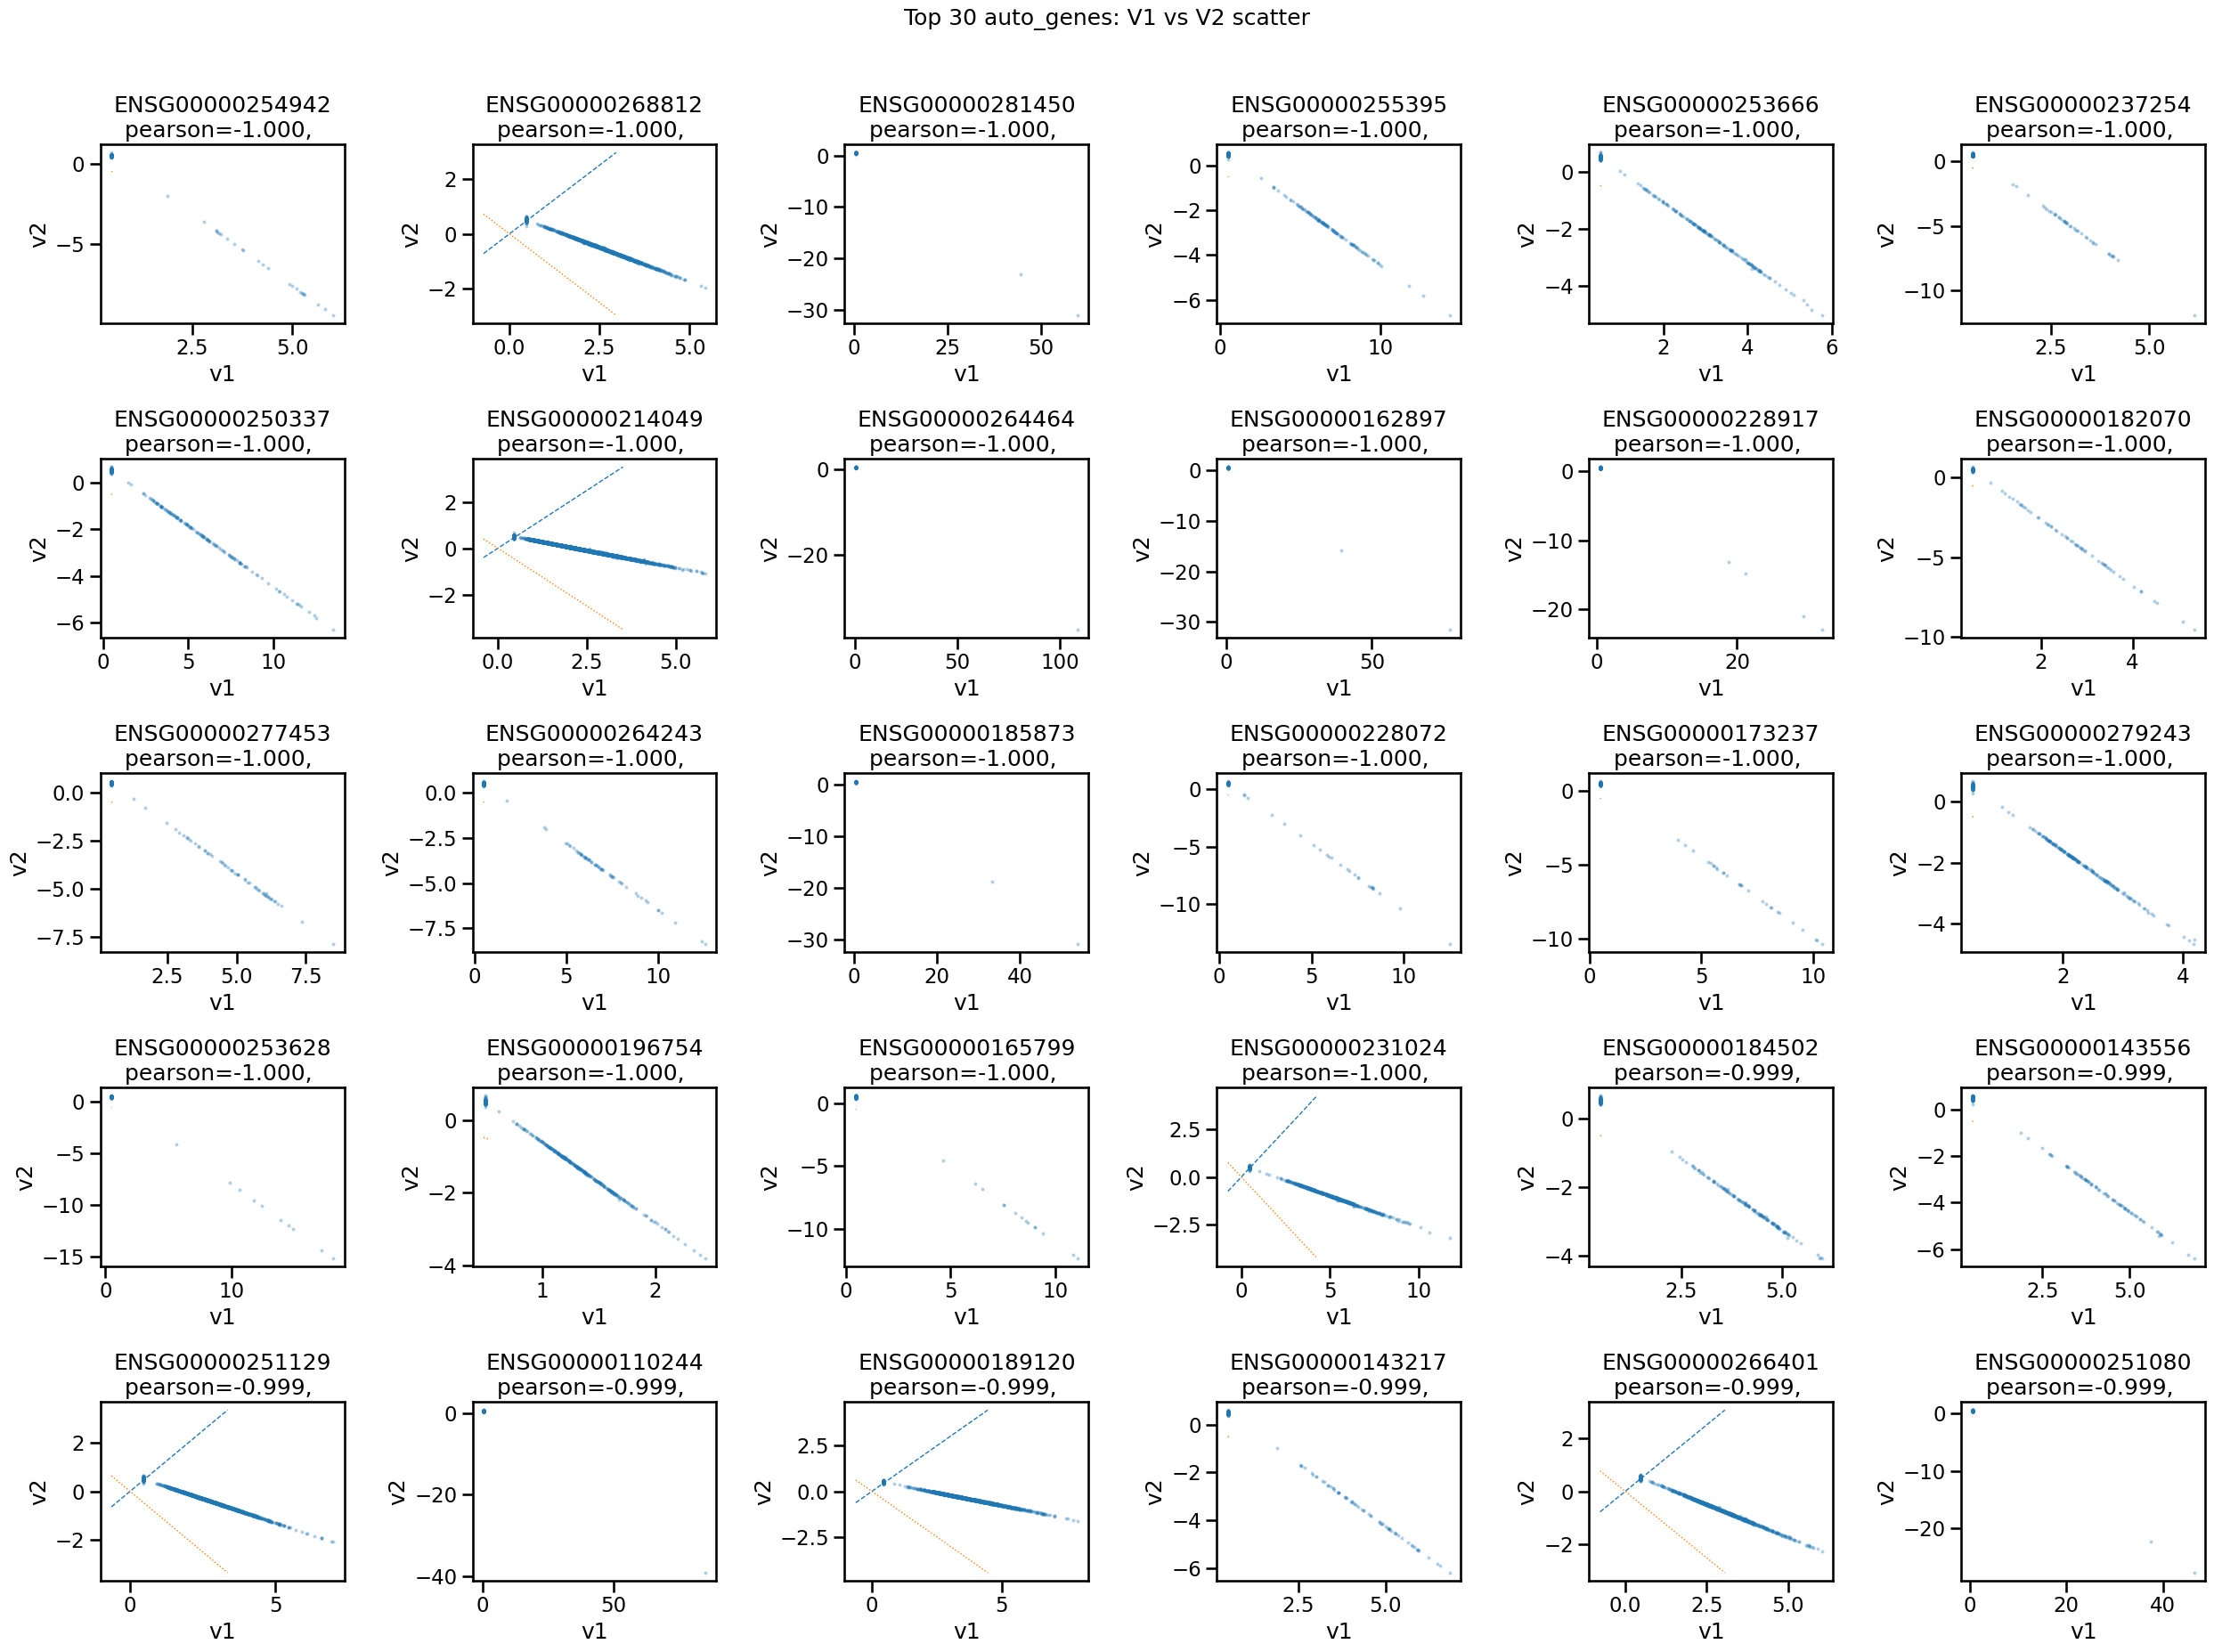

In [19]:
from pathlib import Path
from typing import Optional, Sequence, Tuple
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_auto_genes_scatter_grid(
    auto_genes: Sequence[str],
    metrics_df: pd.DataFrame,
    V1: np.ndarray,
    V2: np.ndarray,
    ncols: int = 6,
    figsize_per_panel: Tuple[float, float] = (4.2, 3.8),
    fig_title: str = "Scatter comparison for auto_genes",
    fig_dir: Optional[Path] = None,
    filename: str = "auto_genes_scatter_grid.png",
    show: bool = True,
):
    """
    auto_genes に含まれる gene について、plot_scatter_v1_v2 を並べて描画する。

    Parameters
    ----------
    auto_genes
        描画したい gene 名の list / sequence
    metrics_df
        gene ごとの metrics を持つ DataFrame
        少なくとも ['gene', 'pearson_r', 'spearman_r', 'slope'] を含むこと
    V1, V2
        gene-specific velocity を取り出す元データ
        get_velocity_vector(V1, gene), get_velocity_vector(V2, gene) で使う
    ncols
        列数。30 個なら 6 を推奨（= 5 x 6）
    figsize_per_panel
        1パネルあたりの大きさ (width, height)
    fig_title
        図全体のタイトル
    fig_dir
        保存先ディレクトリ
    filename
        保存ファイル名
    show
        True なら plt.show()、False なら fig, axes を返す

    Returns
    -------
    fig, axes
        show=False のとき返す
    """
    auto_genes = list(auto_genes)
    n = len(auto_genes)
    if n == 0:
        raise ValueError("auto_genes is empty")

    nrows = math.ceil(n / ncols)
    fig_w = figsize_per_panel[0] * ncols
    fig_h = figsize_per_panel[1] * nrows

    fig, axes = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h), squeeze=False)
    axes_flat = axes.ravel()

    # gene -> metrics row を引きやすくする
    if "gene" not in metrics_df.columns:
        raise KeyError("'gene' column not found in metrics_df")

    metrics_indexed = metrics_df.set_index("gene", drop=False)

    for i, gene in enumerate(auto_genes):
        ax = axes_flat[i]

        if gene not in metrics_indexed.index:
            ax.axis("off")
            ax.text(
                0.5, 0.5,
                f"{gene}\nnot found in metrics_df",
                ha="center", va="center", fontsize=11
            )
            continue

        row = metrics_indexed.loc[gene]

        # 同名 gene が複数行ある場合への保険
        if isinstance(row, pd.DataFrame):
            row = row.iloc[0]

        v1 = get_velocity_vector(V1, gene)
        v2 = get_velocity_vector(V2, gene)

        plot_scatter_v1_v2(ax, v1, v2, gene, row)

    # 余った axes を非表示
    for j in range(n, len(axes_flat)):
        axes_flat[j].axis("off")

    fig.suptitle(fig_title, fontsize=18)

    # suptitle 分だけ少し上を空ける
    fig.tight_layout(rect=[0, 0, 1, 0.97])

    if fig_dir is not None:
        fig_dir.mkdir(parents=True, exist_ok=True)
        fig.savefig(fig_dir / filename, dpi=200, bbox_inches="tight")

    if show:
        plt.show()
    else:
        return fig, axes

plot_auto_genes_scatter_grid(
    auto_genes=auto_genes,
    metrics_df=metrics_df,
    V1=V1,
    V2=V2,
    ncols=6,   # 30個なら 6列 x 5行 が見やすい
    figsize_per_panel=(4.2, 3.8),
    fig_title="Top 30 auto_genes: V1 vs V2 scatter",
    fig_dir=Path("./figures"),
    filename="auto_genes_scatter_grid.png",
    show=True,
)